In [1]:
pwd

'/Users/nesh/Documents/Repositories/icecontinuum/Sample code'

## Run_QLC

This code solves the QLC problem in Cartesian as well as Fourier space. Parameters include:
- $\overline N$, and $N^*$ (atomistic-level characteristics of the ice QLL thicknesses)
- $\sigma_o$ (difference in equilibrium supersaturation between microsurfaces I and II)
- $h_{pr}$ (thickness of a prismatic facet monolayer)
- $D_{surf}$ (surface diffusion coefficient of the QLL)
- $\nu_{kin}$ (kinetic velocity -- the rate at which water vapor strikes the surface)
- $L$ (physical length of the facet surface)
- $nx_{crystal}$ (number of discrete points used to represent the surface)
- $L$ (crystal dimension)
- $\sigma_{I,corner}$ (imposed supersaturation at the facet corner)
- $c_r$ (relative reduction in supersaturation at facet centers relative to corners, in fraction and %)
- $\tau_{eq}$ (time constant for ice/QLL freezing/thawing) (same as $t_{eq}$)

In [4]:
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import numpy as np
import matplotlib.pylab as plt
from time import time

import sys
import QLCstuff as QLC
import importlib  # Import the importlib module (importlib.reload(QLC) reload it)
import f90nml

In [5]:
%matplotlib inline
ticklabelsize = 15
linewidth = 1
fontsize = 15
titlefontsize = 8
markersize = 10

# Constants
R = AssignQuantity(8.314462618,'J /mol / kelvin')
M_H2O = AssignQuantity(18.015,'g/mol')
rho_ice = AssignQuantity(0.917,'g/cm^3')

### Parameters defining the system we're interested in

### Parameters fom the runtime namelist 

In [24]:
RT=f90nml.read(inputfile)['RT'] # Read the main parameter namelist

# How long
runtime = RT['runtime']
runtime_units = RT['runtime_units']
runtime = AssignQuantity(runtime,runtime_units)
print('runtime =', runtime)
runtime.ito('microsecond')

# Number of time steps to keep for reporting later
ntimes = RT['ntimes']

# Flag if we want more output
verbose = RT['verbose']

# Specify the time interval and initial conditions
tkeep_1Darr = np.linspace(0,runtime,ntimes)
Ntot_init_1D = np.ones(nx_crystal)
NQLL_init_1D = QLC.getNQLL(Ntot_init_1D,Nstar,Nbar)

print('This is a run from time', tkeep_1Darr[0].to('msec'),'to', tkeep_1Darr[-1].to('msec'))
print('dt =', tkeep_1Darr[1]-tkeep_1Darr[0])

runtime = 300 millisecond
This is a run from time 0.0 millisecond to 300.0 millisecond
dt = 6122.448979591837 microsecond


### Run the scenario in Cartesian space

In [ ]:
# Runs the simulation
Ntotkeep_1D, NQLLkeep_1D = QLC.run_f1d(\
           NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
           Nbar, Nstar, sigma0, nu_kin, Doverdeltax2, tau_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod=odemethod)
Nicekeep_1D = Ntotkeep_1D-NQLLkeep_1D

# Label for graphs
title_params = \
        "{:.0f}".format(L.magnitude)+' '+str(L.units)+\
        ", "+np.format_float_scientific(D.magnitude,precision=2)+" "+str(D.units)+\
        "\n"+\
        "{:.0f}".format(nu_kin.magnitude)+' '+str(nu_kin.units)+\
        "\n"+\
        "{:.3f}".format(sigmaI_corner.magnitude)+' '+str(sigmaI_corner.units)+\
        ", "+"{:.1f}".format(tau_eq.magnitude)+' '+str(tau_eq.units)+\
        ", "+"{:.3f}".format(c_r.to('percent').magnitude)+'%'+\
        ", "+odemethod+\
        "\n"

# Graphical output
g_ice_QLC = QLC.report_1d_growth_results(\
        x_QLC,tkeep_1Darr,NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,h_pr, \
        graphics=True,title_params=title_params)

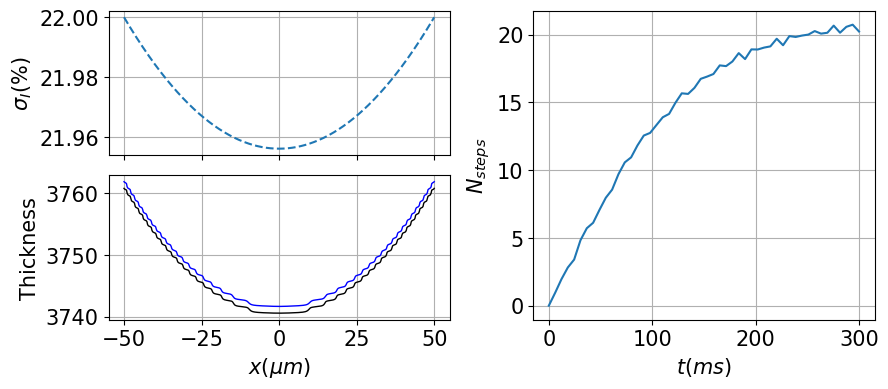

In [109]:
QLC.report_1d_growth_results_with_sigma(x_QLC,tkeep_1Darr.to('millisecond'),NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,sigmaI_QLC*100)

### Run the scenario in FT space for comparison

In [ ]:
# Runs the simulation
DoverL2pi2 = D/L**2*np.pi**2
Ntotkeep_1D_FT, NQLLkeep_1D_FT = QLC.run_f1d_FT(\
           NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
           Nbar, Nstar, sigma0, nu_kin, DoverL2pi2, tau_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod='RK45') # RK45 allows integration of complex functions (but LSODA does not)
Nicekeep_1D_FT = Ntotkeep_1D_FT - NQLLkeep_1D_FT

# Graphical output
QLC.report_1d_growth_results_with_sigma(x_QLC,tkeep_1Darr.to('millisecond'),NQLLkeep_1D_FT,Ntotkeep_1D_FT,Nicekeep_1D_FT,sigmaI_QLC*100)